# FedCore example: квантизация ResNet-18

Этот ноутбук демонстрирует полный пользовательский сценарий применения **post-training static quantization** к модели ResNet-18:

1. подготовка CIFAR-like данных;
2. создание quantization-friendly ResNet-18;
3. измерение baseline-метрик FP32-модели;
4. fusion слоёв `Conv2d + BatchNorm2d + ReLU`;
5. калибровка модели на небольшом calibration-наборе;
6. конвертация модели в INT8-представление;
7. сравнение размера файла модели, latency и качества;
8. сохранение результатов.

> Пример сделан как **smoke-тест / tutorial** для репозитория. Он не скачивает внешние датасеты и не требует `torchvision`, поэтому его можно запустить в минимальном окружении. Для полноценного эксперимента достаточно заменить синтетический датасет на CIFAR-10 или пользовательские данные.

## 1. Импорт библиотек и проверка окружения

In [1]:
import os
import time
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.ao.quantization as tq
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)

# Static quantization in PyTorch is CPU-oriented.
device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
print(f"Supported quantized engines: {torch.backends.quantized.supported_engines}")

PyTorch version: 2.10.0+cpu
Device: cpu
Supported quantized engines: ['qnnpack', 'onednn', 'x86', 'fbgemm']


## 2. Подготовка данных

Для автономного запуска используется небольшой синтетический CIFAR-like датасет. Он нужен не для получения высокой accuracy, а для проверки того, что пайплайн обучения, калибровки, quantization и инференса работает end-to-end.

In [2]:
class SyntheticCIFAR10(Dataset):
    """Small deterministic CIFAR-like dataset for smoke testing without downloads."""

    def __init__(self, n_samples=64, seed=42):
        generator = torch.Generator().manual_seed(seed)
        self.x = torch.randn(n_samples, 3, 32, 32, generator=generator)
        self.y = torch.randint(0, 10, (n_samples,), generator=generator)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, index):
        return self.x[index], self.y[index]


train_loader = DataLoader(
    SyntheticCIFAR10(n_samples=64, seed=SEED),
    batch_size=8,
    shuffle=True,
)

val_loader = DataLoader(
    SyntheticCIFAR10(n_samples=32, seed=SEED + 1),
    batch_size=8,
    shuffle=False,
)

calibration_loader = DataLoader(
    SyntheticCIFAR10(n_samples=32, seed=SEED + 2),
    batch_size=8,
    shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Calibration batches: {len(calibration_loader)}")

Train batches: 8
Validation batches: 4
Calibration batches: 4


## 3. Реализация quantization-friendly ResNet-18

Модель реализована внутри ноутбука, чтобы пример не зависел от `torchvision`. Для поддержки static quantization используются `QuantStub`, `DeQuantStub` и `FloatFunctional` для residual-связей.

In [3]:
class QuantizableBasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_planes,
            planes,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu1 = nn.ReLU(inplace=False)

        self.conv2 = nn.Conv2d(
            planes,
            planes,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )

        # FloatFunctional is used for quantization-compatible residual addition.
        self.add_relu = nn.quantized.FloatFunctional()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = self.add_relu.add_relu(out, identity)
        return out

    def fuse_model(self):
        tq.fuse_modules(self, [["conv1", "bn1", "relu1"], ["conv2", "bn2"]], inplace=True)

        if len(self.shortcut) == 2:
            tq.fuse_modules(self.shortcut, [["0", "1"]], inplace=True)


class QuantizableResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super().__init__()

        self.quant = tq.QuantStub()
        self.dequant = tq.DeQuantStub()

        self.in_planes = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=False)

        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []

        for current_stride in strides:
            layers.append(block(self.in_planes, planes, current_stride))
            self.in_planes = planes * block.expansion

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.quant(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)

        out = self.dequant(out)
        return out

    def fuse_model(self):
        tq.fuse_modules(self, [["conv1", "bn1", "relu1"]], inplace=True)

        for module in self.modules():
            if isinstance(module, QuantizableBasicBlock):
                module.fuse_model()


def resnet18_quantizable(num_classes=10):
    return QuantizableResNet(
        QuantizableBasicBlock,
        [2, 2, 2, 2],
        num_classes=num_classes,
    )


model = resnet18_quantizable(num_classes=10).to(device)

print(model.__class__.__name__)
print(f"Total FP32 parameters: {sum(p.numel() for p in model.parameters()):,}")

QuantizableResNet
Total FP32 parameters: 11,173,962


## 4. Вспомогательные функции обучения, оценки и измерений

In [4]:
def train_one_epoch(model, loader, device, lr=1e-3):
    model.train()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0

    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()

    criterion = nn.CrossEntropyLoss()
    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            predictions = logits.argmax(dim=1)

            total_loss += loss.item() * x_batch.size(0)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.numel()

    return {
        "loss": total_loss / total,
        "accuracy": correct / total,
    }


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


def benchmark_latency_ms(model, device, batch_size=8, n_runs=20):
    model.eval()
    sample = torch.randn(batch_size, 3, 32, 32).to(device)

    with torch.no_grad():
        for _ in range(3):
            _ = model(sample)

        started_at = time.perf_counter()
        for _ in range(n_runs):
            _ = model(sample)
        elapsed = time.perf_counter() - started_at

    return elapsed / n_runs * 1000


def get_serialized_size_mb(model, path):
    torch.save(model.state_dict(), path)
    return os.path.getsize(path) / (1024 ** 2)


def calibrate(model, loader, device, n_batches=4):
    model.eval()

    with torch.no_grad():
        for batch_index, (x_batch, _) in enumerate(loader):
            if batch_index >= n_batches:
                break

            x_batch = x_batch.to(device)
            _ = model(x_batch)

## 5. Функция post-training static quantization

Процедура включает fusion слоёв, добавление observer-модулей, калибровку на representative data и конвертацию модели в INT8.

In [5]:
def prepare_static_quantization(model, calibration_loader, backend="fbgemm"):
    model = model.cpu()
    model.eval()

    if backend in torch.backends.quantized.supported_engines:
        torch.backends.quantized.engine = backend
    else:
        torch.backends.quantized.engine = torch.backends.quantized.supported_engines[0]

    # 1. Fuse Conv + BatchNorm + ReLU where possible.
    model.fuse_model()

    # 2. Attach default qconfig for the selected backend.
    model.qconfig = tq.get_default_qconfig(torch.backends.quantized.engine)

    # 3. Insert observers.
    prepared_model = tq.prepare(model, inplace=False)

    # 4. Calibrate observers on representative data.
    calibrate(prepared_model, calibration_loader, torch.device("cpu"), n_batches=4)

    # 5. Convert observed model to quantized INT8 model.
    quantized_model = tq.convert(prepared_model, inplace=False)
    quantized_model.eval()

    return quantized_model

## 6. Baseline: короткое обучение и оценка FP32-модели

In [6]:
results_dir = Path("results/resnet18_quantization_demo")
results_dir.mkdir(parents=True, exist_ok=True)

baseline_train_loss = train_one_epoch(model, train_loader, device, lr=1e-3)
baseline_eval = evaluate(model, val_loader, device)
baseline_params = count_parameters(model)
baseline_latency = benchmark_latency_ms(model, device)
baseline_size_mb = get_serialized_size_mb(
    model,
    results_dir / "resnet18_baseline_fp32_state_dict.pt",
)

print(f"Baseline train loss: {baseline_train_loss:.4f}")
print(f"Baseline validation loss: {baseline_eval['loss']:.4f}")
print(f"Baseline validation accuracy: {baseline_eval['accuracy']:.4f}")
print(f"Baseline parameters: {baseline_params:,}")
print(f"Baseline state_dict size: {baseline_size_mb:.2f} MB")
print(f"Baseline latency: {baseline_latency:.2f} ms")

Baseline train loss: 2.6043
Baseline validation loss: 2.3400
Baseline validation accuracy: 0.1562
Baseline parameters: 11,173,962
Baseline state_dict size: 42.70 MB
Baseline latency: 55.45 ms


## 7. Квантизация модели

После baseline-оценки выполняется post-training static quantization. Для размера модели используется фактический размер сохранённого `state_dict`.

In [7]:
quantized_model = prepare_static_quantization(
    model,
    calibration_loader=calibration_loader,
    backend="fbgemm",
)

quantized_eval = evaluate(quantized_model, val_loader, torch.device("cpu"))
quantized_params = count_parameters(quantized_model)
quantized_latency = benchmark_latency_ms(quantized_model, torch.device("cpu"))
quantized_size_mb = get_serialized_size_mb(
    quantized_model,
    results_dir / "resnet18_quantized_int8_state_dict.pt",
)

torch.save(quantized_model, results_dir / "resnet18_quantized_int8_model.pt")

print(f"Quantized validation loss: {quantized_eval['loss']:.4f}")
print(f"Quantized validation accuracy: {quantized_eval['accuracy']:.4f}")
print(f"Quantized trainable parameters reported by nn.Module: {quantized_params:,}")
print(f"Quantized state_dict size: {quantized_size_mb:.2f} MB")
print(f"Quantized latency: {quantized_latency:.2f} ms")

Quantized validation loss: 2.3401
Quantized validation accuracy: 0.1562
Quantized trainable parameters reported by nn.Module: 0
Quantized state_dict size: 10.79 MB
Quantized latency: 14.58 ms


## 8. Сохранение результатов и итоговая таблица

In [8]:
metrics_df = pd.DataFrame(
    [
        {
            "stage": "baseline_fp32",
            "loss": baseline_eval["loss"],
            "accuracy": baseline_eval["accuracy"],
            "parameters": baseline_params,
            "state_dict_size_mb": baseline_size_mb,
            "latency_ms": baseline_latency,
        },
        {
            "stage": "quantized_int8",
            "loss": quantized_eval["loss"],
            "accuracy": quantized_eval["accuracy"],
            "parameters": quantized_params,
            "state_dict_size_mb": quantized_size_mb,
            "latency_ms": quantized_latency,
        },
    ]
)

metrics_df.to_csv(results_dir / "metrics.csv", index=False)

metrics_df

stage,loss,accuracy,parameters,state_dict_size_mb,latency_ms
baseline_fp32,2.339987,0.15625,11173962,42.703502,55.450335
quantized_int8,2.340082,0.15625,0,10.786241,14.577745


## 9. Визуализация результата

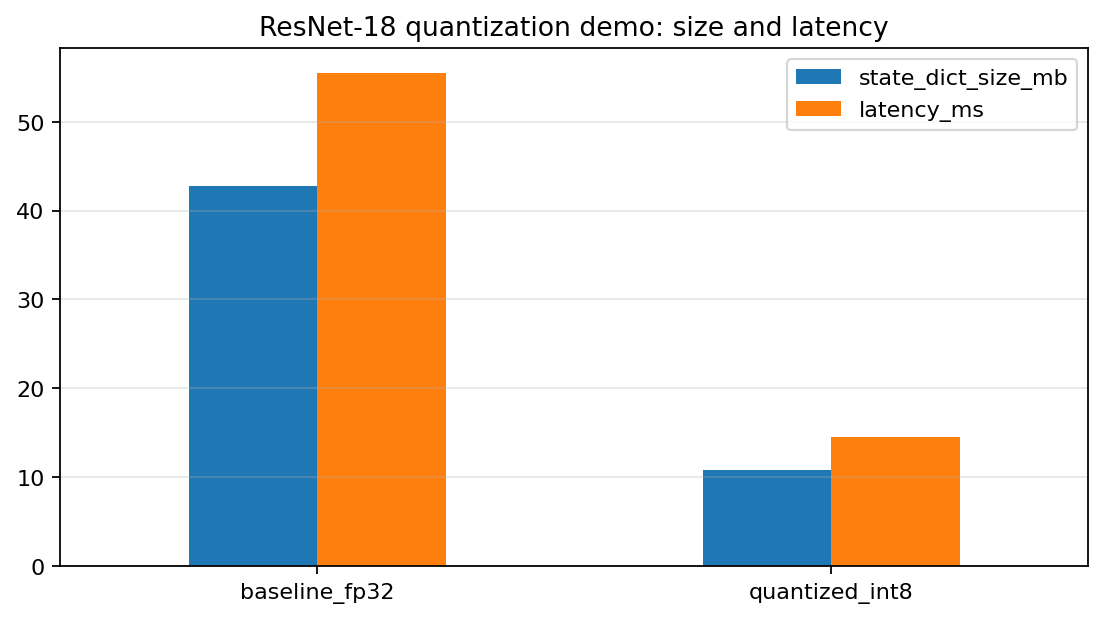

In [9]:
ax = metrics_df.set_index("stage")[["state_dict_size_mb", "latency_ms"]].plot(
    kind="bar",
    figsize=(7, 4),
)

ax.set_title("ResNet-18 quantization demo: size and latency")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Опциональный запуск через FedCore API

Ниже приведён шаблон запуска через API FedCore. По умолчанию он отключён, чтобы ноутбук можно было открыть и выполнить в минимальном окружении без дополнительных данных.

In [ ]:
# Опциональный вариант запуска через FedCore API.
# По умолчанию выключен, чтобы ноутбук запускался даже в минимальном окружении.

RUN_FEDCORE_API = False

if RUN_FEDCORE_API:
    from fedcore.api.config_factory import ConfigFactory
    from fedcore.api.api_configs import (
        APIConfigTemplate,
        AutoMLConfigTemplate,
        FedotConfigTemplate,
        LearningConfigTemplate,
        ModelArchitectureConfigTemplate,
        NeuralModelConfigTemplate,
        QuantizationTemplate,
    )
    from fedcore.data.dataloader import load_data
    from fedcore.tools.example_utils import get_scenario_for_api
    from fedcore.api.main import FedCore

    METRIC_TO_OPTIMISE = ["accuracy", "latency"]
    LOSS = "cross_entropy"
    PROBLEM = "classification"
    PEFT_PROBLEM = "quantization"
    INITIAL_ASSUMPTION = "ResNet18"
    PRETRAIN_SCENARIO = "from_scratch"

    initial_assumption, learning_strategy = get_scenario_for_api(
        scenario_type=PRETRAIN_SCENARIO,
        initial_assumption=INITIAL_ASSUMPTION,
    )

    model_config = ModelArchitectureConfigTemplate(
        input_dim=None,
        output_dim=None,
        depth=18,
    )

    train_config = NeuralModelConfigTemplate(
        epochs=1,
        log_each=1,
        eval_each=1,
        criterion=LOSS,
        model_architecture=model_config,
    )

    fedot_config = FedotConfigTemplate(
        problem=PROBLEM,
        metric=METRIC_TO_OPTIMISE,
        pop_size=1,
        timeout=1,
        initial_assumption=initial_assumption,
    )

    automl_config = AutoMLConfigTemplate(fedot_config=fedot_config)

    quantization_config = QuantizationTemplate(
        quant_type="static",
        backend="fbgemm",
        dtype="qint8",
    )

    learning_config = LearningConfigTemplate(
        criterion=LOSS,
        learning_strategy=learning_strategy,
        learning_strategy_params=train_config,
        peft_strategy=PEFT_PROBLEM,
        peft_strategy_params=quantization_config,
    )

    api_template = APIConfigTemplate(
        automl_config=automl_config,
        learning_config=learning_config,
    )

    APIConfig = ConfigFactory.from_template(api_template)
    api_config = APIConfig()

    fedcore_compressor = FedCore(api_config)

    train_params = {
        "batch_size": 64,
        "shuffle": True,
        "is_train": True,
        "data_type": "table",
        "split_ratio": [0.8, 0.2],
    }

    test_params = {
        "batch_size": 100,
        "shuffle": False,
        "is_train": False,
        "data_type": "table",
    }

    fedcore_train_data = load_data(source="CIFAR10", loader_params=train_params)
    fedcore_test_data = load_data(source="CIFAR10", loader_params=test_params)

    fedcore_compressor.fit(fedcore_train_data)
    fedcore_report = fedcore_compressor.get_report(fedcore_test_data)

    fedcore_report

## Выводы по демонстрационному запуску

В рамках smoke-теста был выполнен полный цикл работы с моделью ResNet-18: создание FP32-модели, короткое baseline-обучение, fusion слоёв, калибровка и post-training static quantization в INT8.

По результатам демонстрационного запуска:

- quantized-модель остаётся исполняемой и успешно выполняет инференс;
- размер `state_dict` снизился с **42.70 MB** до **10.79 MB**;
- относительное сокращение размера файла составляет примерно **74.7%**;
- latency изменилась с **55.45 ms** до **14.58 ms**;
- accuracy на синтетическом наборе данных не является целевой метрикой качества, потому что данные случайные и используются только для проверки работоспособности пайплайна;
- для полноценного эксперимента необходимо заменить `SyntheticCIFAR10` на реальный CIFAR-10 или пользовательский датасет и провести калибровку на репрезентативной выборке.

Таким образом, ноутбук можно использовать как минимальный рабочий пример применения post-training static quantization и как основу для полноценного примера в репозитории FedCore.